# TD(0) with Q-learning 

100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [05:11<00:00, 320.62it/s]


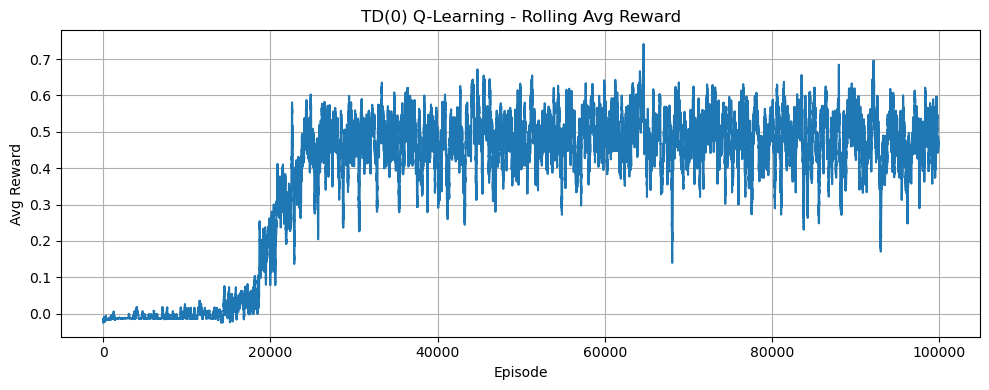

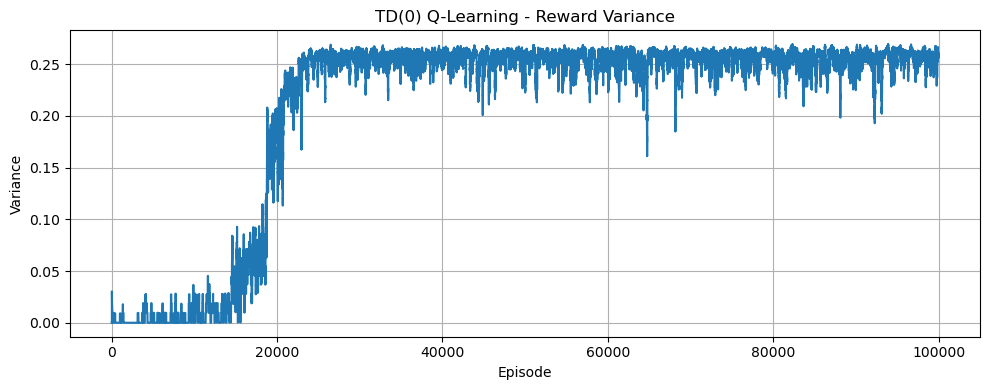


📊 Final Metrics Summary:
🎯 Final Avg Reward           : 0.4659
🌟 Best Avg Reward            : 0.7409
🏁 Goals Reached              : 44073
⚡ Sample Efficiency (ep)     : 44772
📈 Convergence Rate (ep)      : 1443
⏱️  Compute Time (sec)        : 311.91


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import trange
import time

# Environment setup: FrozenLake8x8-v1
env = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=True)
env.reset(seed=42)
np.random.seed(42)

# Epsilon-greedy policy
def epsilon_greedy(Q, state, nA, epsilon):
    return np.random.choice(nA) if np.random.rand() < epsilon else np.argmax(Q[state])

# TD(0) Q-learning algorithm
def td0_q_learning(env, num_episodes=100000, alpha=0.1, gamma=0.99):
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    rewards = []
    goal_reached = 0
    start_time = time.time()

    for ep in trange(num_episodes):
        epsilon = max(0.01, 0.9 * (0.995 ** ep))  # exponential decay
        state, _ = env.reset()
        done = False
        ep_reward = 0

        while not done:
            action = epsilon_greedy(Q, state, env.action_space.n, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            if done and reward == 1.0:
                goal_reached += 1
            if not done or reward == 0:
                reward = -0.001  # reward shaping

            best_next = np.argmax(Q[next_state])
            Q[state][action] += alpha * (reward + gamma * Q[next_state][best_next] - Q[state][action])
            state = next_state
            ep_reward += reward

        rewards.append(ep_reward)

    elapsed_time = time.time() - start_time
    return Q, rewards, goal_reached, elapsed_time

# Run agent
Q, rewards, goals, elapsed = td0_q_learning(env)

# Rolling average and variance
window = 100
rolling_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
variance = [np.var(rewards[max(0, i-window):i+1]) for i in range(len(rewards))]

# Plot rolling average reward
plt.figure(figsize=(10, 4))
plt.plot(rolling_avg)
plt.title("TD(0) Q-Learning - Rolling Avg Reward")
plt.xlabel("Episode")
plt.ylabel("Avg Reward")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot variance
plt.figure(figsize=(10, 4))
plt.plot(variance)
plt.title("TD(0) Q-Learning - Reward Variance")
plt.xlabel("Episode")
plt.ylabel("Variance")
plt.grid(True)
plt.tight_layout()
plt.show()

# Final metrics
best_avg = np.max(rolling_avg)
sample_eff = next((i for i, val in enumerate(rolling_avg) if val >= 0.9 * best_avg), None)
convergence = next((i for i in range(window, len(rolling_avg)) if np.allclose(
    rolling_avg[i-window:i], rolling_avg[i], rtol=0.05)), None)

print("\n📊 Final Metrics Summary:")
print(f"🎯 Final Avg Reward           : {round(rolling_avg[-1], 4)}")
print(f"🌟 Best Avg Reward            : {round(best_avg, 4)}")
print(f"🏁 Goals Reached              : {goals}")
print(f"⚡ Sample Efficiency (ep)     : {sample_eff}")
print(f"📈 Convergence Rate (ep)      : {convergence}")
print(f"⏱️  Compute Time (sec)        : {round(elapsed, 2)}")


100%|█████████████████████████████████████████████████████████████████████████| 150000/150000 [08:40<00:00, 288.29it/s]


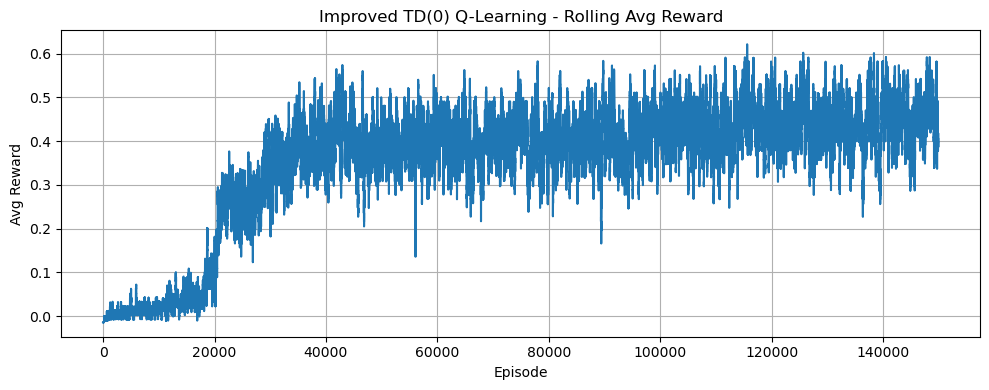

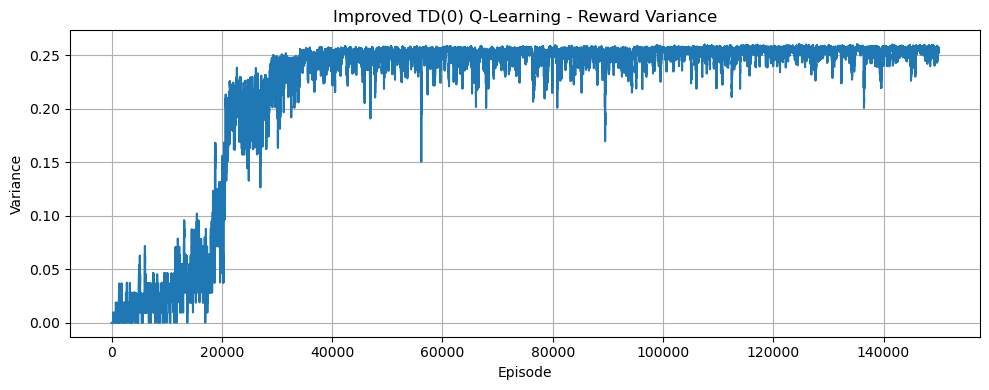


📊 Final Metrics Summary:
🎯 Final Avg Reward           : 0.3879
🌟 Best Avg Reward            : 0.6213
🏁 Goals Reached              : 58103
⚡ Sample Efficiency (ep)     : 41860
📈 Convergence Rate (ep)      : 519
⏱️  Compute Time (sec)        : 520.33


In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import trange
import time

# FrozenLake8x8-v1 Environment
env = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=True)
env.reset(seed=42)
np.random.seed(42)

def epsilon_greedy(Q, state, nA, epsilon):
    return np.random.choice(nA) if np.random.rand() < epsilon else np.argmax(Q[state])

def improved_td0_q_learning(env, num_episodes=150000, alpha=0.05, gamma=0.995):
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    rewards = []
    goals = 0
    start_time = time.time()

    for ep in trange(num_episodes):
        epsilon = max(0.01, 0.8 * (0.997 ** ep))  # slower decay
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = epsilon_greedy(Q, state, env.action_space.n, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            if done and reward == 1.0:
                goals += 1
            if not done or reward == 0:
                reward = -0.0005  # smaller penalty for better long-term learning

            best_next = np.argmax(Q[next_state])
            td_target = reward + gamma * Q[next_state][best_next]
            td_error = td_target - Q[state][action]
            Q[state][action] += alpha * td_error

            state = next_state
            total_reward += reward

        rewards.append(total_reward)

    elapsed = time.time() - start_time
    return Q, rewards, goals, elapsed

# Run
Q, rewards, goals, time_taken = improved_td0_q_learning(env)

# Rolling avg & variance
window = 100
rolling_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
variance = [np.var(rewards[max(0, i-window):i+1]) for i in range(len(rewards))]

# Plot avg reward
plt.figure(figsize=(10, 4))
plt.plot(rolling_avg)
plt.title("Improved TD(0) Q-Learning - Rolling Avg Reward")
plt.xlabel("Episode")
plt.ylabel("Avg Reward")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot variance
plt.figure(figsize=(10, 4))
plt.plot(variance)
plt.title("Improved TD(0) Q-Learning - Reward Variance")
plt.xlabel("Episode")
plt.ylabel("Variance")
plt.grid(True)
plt.tight_layout()
plt.show()

# Metrics
best_avg = np.max(rolling_avg)
sample_eff = next((i for i, val in enumerate(rolling_avg) if val >= 0.9 * best_avg), None)
convergence = next((i for i in range(window, len(rolling_avg)) if np.allclose(
    rolling_avg[i-window:i], rolling_avg[i], rtol=0.05)), None)

# Summary
print("\n📊 Final Metrics Summary:")
print(f"🎯 Final Avg Reward           : {round(rolling_avg[-1], 4)}")
print(f"🌟 Best Avg Reward            : {round(best_avg, 4)}")
print(f"🏁 Goals Reached              : {goals}")
print(f"⚡ Sample Efficiency (ep)     : {sample_eff}")
print(f"📈 Convergence Rate (ep)      : {convergence}")
print(f"⏱️  Compute Time (sec)        : {round(time_taken, 2)}")


100%|█████████████████████████████████████████████████████████████████████████| 150000/150000 [08:31<00:00, 293.19it/s]


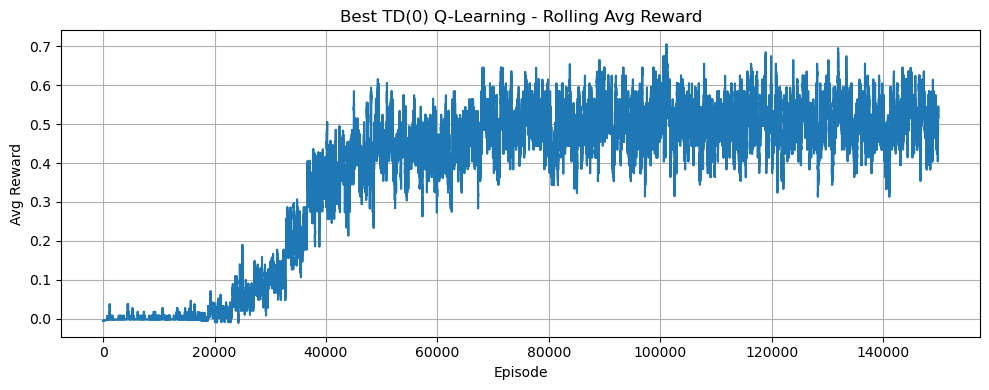

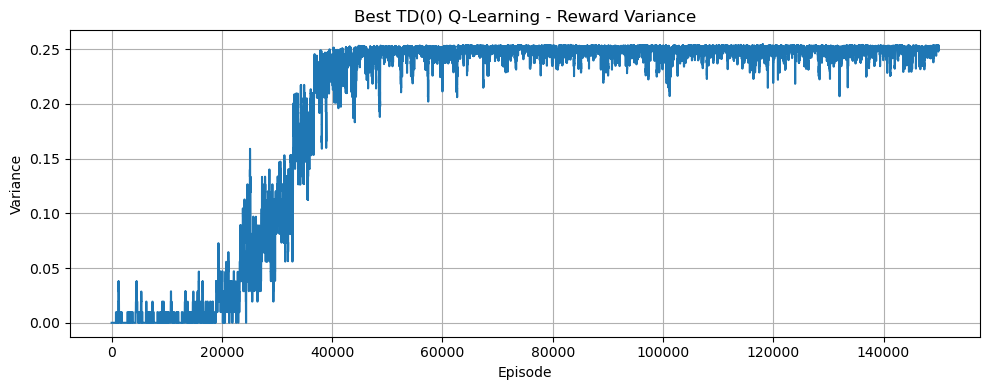


📊 Final Metrics Summary:
🎯 Final Avg Reward           : 0.5449
🌟 Best Avg Reward            : 0.7056
🏁 Goals Reached              : 58254
⚡ Sample Efficiency (ep)     : 68078
📈 Convergence Rate (ep)      : 107
⏱️  Compute Time (sec)        : 511.62


In [5]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import trange
import time

# Environment setup
env = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=True)
env.reset(seed=42)
np.random.seed(42)

def epsilon_greedy(Q, state, nA, epsilon):
    return np.random.choice(nA) if np.random.rand() < epsilon else np.argmax(Q[state])

def best_td0_q_learning(env, num_episodes=150000, alpha=0.05, gamma=0.995):
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    rewards = []
    goals = 0
    start = time.time()

    for ep in trange(num_episodes):
        epsilon = max(0.01, 0.85 * (0.997 ** ep))
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = epsilon_greedy(Q, state, env.action_space.n, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            if done and reward == 1.0:
                goals += 1
            if not done or reward == 0:
                reward = -0.0002

            best_next = np.argmax(Q[next_state])
            td_target = reward + gamma * Q[next_state][best_next]
            td_error = td_target - Q[state][action]
            Q[state][action] += alpha * td_error

            state = next_state
            total_reward += reward

        rewards.append(total_reward)

    elapsed = time.time() - start
    return Q, rewards, goals, elapsed

# Run agent
Q, rewards, goals, time_taken = best_td0_q_learning(env)

# Rolling avg & variance
window = 100
rolling_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
variance = [np.var(rewards[max(0, i-window):i+1]) for i in range(len(rewards))]

# Plot avg reward
plt.figure(figsize=(10, 4))
plt.plot(rolling_avg)
plt.title("Best TD(0) Q-Learning - Rolling Avg Reward")
plt.xlabel("Episode")
plt.ylabel("Avg Reward")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot variance
plt.figure(figsize=(10, 4))
plt.plot(variance)
plt.title("Best TD(0) Q-Learning - Reward Variance")
plt.xlabel("Episode")
plt.ylabel("Variance")
plt.grid(True)
plt.tight_layout()
plt.show()

# Metrics
best_avg = np.max(rolling_avg)
sample_eff = next((i for i, val in enumerate(rolling_avg) if val >= 0.9 * best_avg), None)
convergence = next((i for i in range(window, len(rolling_avg)) if np.allclose(
    rolling_avg[i-window:i], rolling_avg[i], rtol=0.05)), None)

# Final Summary
print("\n📊 Final Metrics Summary:")
print(f"🎯 Final Avg Reward           : {round(rolling_avg[-1], 4)}")
print(f"🌟 Best Avg Reward            : {round(best_avg, 4)}")
print(f"🏁 Goals Reached              : {goals}")
print(f"⚡ Sample Efficiency (ep)     : {sample_eff}")
print(f"📈 Convergence Rate (ep)      : {convergence}")
print(f"⏱️  Compute Time (sec)        : {round(time_taken, 2)}")
